# Event-Driven Backtester: SMA Crossover (20/200) on SPY

**Author:** Ayaan Khalid  

---

## Overview

This project builds an **event-driven backtester from scratch** in python to test a classic SMA crossover strategy on the S&P 500 ETF (SPY).

### Strategy: 20/200 SMA Crossover
- **Buy** when the 20-day Simple Moving Average crosses **above** the 200-day SMA (golden cross --> bullish signal)
- **Sell** when the 20-day SMA crosses **below** the 200-day SMA (death cross --> bearish signal)

### Why event-driven?
Unlike vectorised backtesting (applying calculations to the whole dataset at once), an event-driven backtester simulates time moving forward **one day at a time** and reacts to signals as they fire (closer to how real trading systems work) and avoids accidental lookahead bias.

### Benchmark
The strategy is compared against a simple **buy-and-hold** of SPY to evaluate whether active trading adds value.


## 1. Imports & Setup

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-darkgrid')
plt.rcParams['figure.dpi'] = 120

## 2. Data

We download daily closing prices for **SPY** (SPDR S&P 500 ETF Trust) from Yahoo Finance, covering January 2020 to June 2026.

In [2]:
df = yf.download("SPY", start="2020-01-01", end="2026-06-01")
df = df[["Close"]]  #only need closing price

print(f"Data range: {df.index[0].date()} to {df.index[-1].date()}")
print(f"Total trading days: {len(df)}")
df.tail()

[*********************100%***********************]  1 of 1 completed

Data range: 2020-01-02 to 2026-05-29
Total trading days: 1610


Price,Close
Ticker,SPY
Date,
2026-05-22,743.723999
2026-05-26,748.661316
2026-05-27,748.531616
2026-05-28,752.660950
2026-05-29,754.536133


## 3. Signal Generation: 20/200 SMA Crossover

We compute the two rolling averages:
- **SMA 20** - short-term trend (reacts quickly to price moves)
- **SMA 200** - long-term trend (slow-moving, widely followed by institutions)

**Signal logic:**
- `+1` (Long) when SMA 20 > SMA 200
- `-1` (Flat) when SMA 20 < SMA 200

In [3]:
df["SMA_fast"] = df["Close"].rolling(20).mean()   #20-day SMA
df["SMA_slow"] = df["Close"].rolling(200).mean()  #200-day SMA

df["signal"] = 0
df.loc[df["SMA_fast"] > df["SMA_slow"], "signal"] = 1   #long
df.loc[df["SMA_fast"] < df["SMA_slow"], "signal"] = -1  #flat

# Preview signals
print("Signal distribution:")
print(df["signal"].value_counts())

Signal distribution:
 1    1139
-1     272
 0     199
Name: signal, dtype: int64


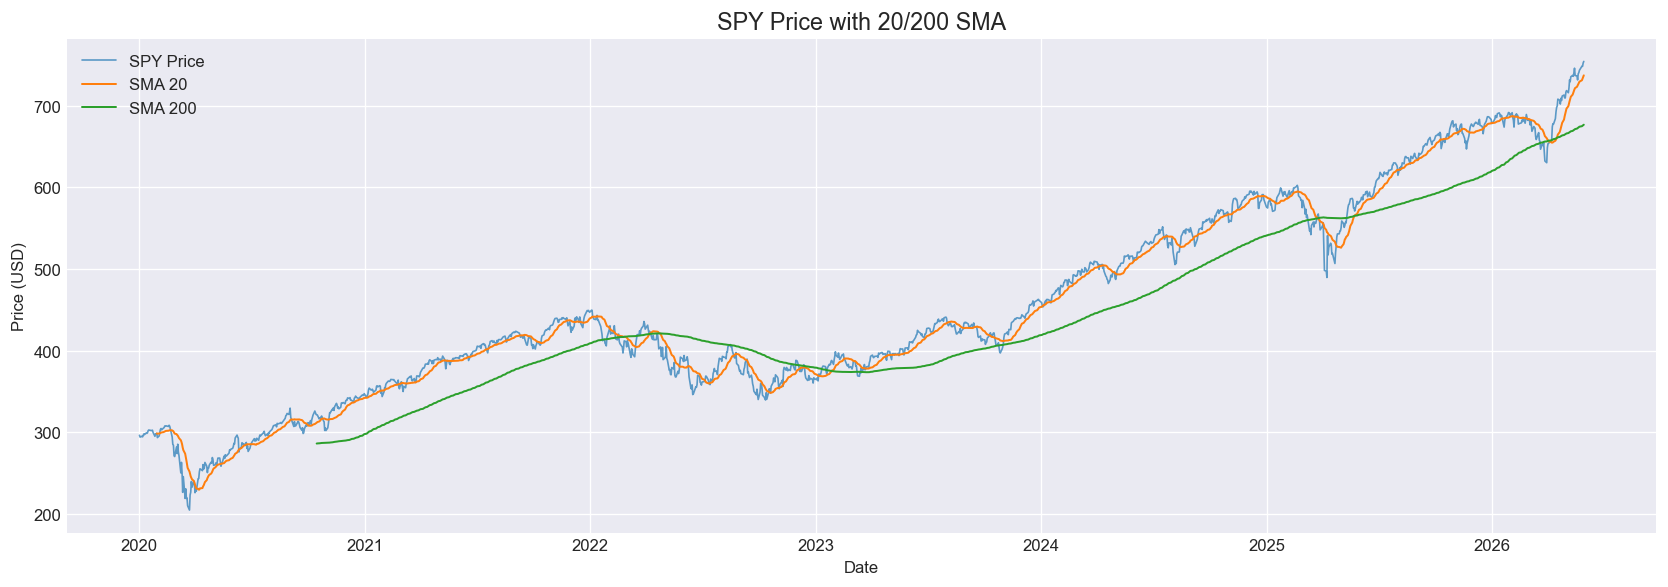

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["Close"], label="SPY Price", alpha=0.7, linewidth=1)
ax.plot(df["SMA_fast"], label="SMA 20", linewidth=1.2)
ax.plot(df["SMA_slow"], label="SMA 200", linewidth=1.2)

ax.set_title("SPY Price with 20/200 SMA", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Event-Driven Backtester

We simulate the strategy by iterating through each trading day and reacting to signals as they appear. Starting capital is **$10,000**.

**Rules:**
- On a buy signal (`+1`): invest all cash into SPY shares
- On a sell signal (`-1`): liquidate all shares back to cash
- Track total portfolio value (cash + market value of shares) at end of each day

> This approach does **not** model transaction costs or slippage

In [5]:
capital = 10000
cash = capital
position = 0  #number of shares held
portfolio_value = []

for i in range(len(df)):
    price = df["Close"].iloc[i].item()
    sig = df["signal"].iloc[i].item()

    #buy signal and not already in position
    if sig == 1 and position == 0:
        position = cash / price  #buy as many shares as possible
        cash = 0

    #exit signal and currently holding
    elif sig == -1 and position > 0:
        cash = position * price  #sell everything
        position = 0

    #track total value
    total = cash + (position * price)
    portfolio_value.append(total)

df["portfolio"] = portfolio_value
print("Backtest complete")

Backtest complete


## 5. Benchmark: Buy & Hold

For comparison, we compute what a simple buy-and-hold of SPY would have returned over the same period, starting with the same $10,000.

In [6]:
df["buy_hold"] = capital * (df["Close"] / df["Close"].iloc[0])

## 6. Performance Metrics

We evaluate both strategies on four key metrics:

| Metric | Description |
|---|---|
| **Final Value** | Portfolio value at end of period |
| **Total PnL** | Profit or loss in dollars |
| **Sharpe Ratio** | Return per unit of risk (annualised) |
| **Max Drawdown** | Worst peak-to-trough decline |

In [7]:
def compute_metrics(series, capital):
    pnl = series.iloc[-1] - capital
    returns = series.pct_change()
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    rolling_max = series.cummax()
    drawdown = (series - rolling_max) / rolling_max
    max_dd = drawdown.min()
    final_value = series.iloc[-1]
    return pnl, sharpe, max_dd, final_value

strat_pnl, strat_sharpe, strat_dd, strat_final = compute_metrics(df["portfolio"], capital)
bh_pnl, bh_sharpe, bh_dd, bh_final = compute_metrics(df["buy_hold"], capital)

print(f"{'Metric':<20} {'SMA Strategy':>15} {'Buy & Hold':>15}")
print("-" * 52)
print(f"{'Final Value':<20} ${strat_final:>14,.2f} ${bh_final:>14,.2f}")
print(f"{'Total PnL':<20} ${strat_pnl:>14,.2f} ${bh_pnl:>14,.2f}")
print(f"{'Sharpe Ratio':<20} {strat_sharpe:>15.2f} {bh_sharpe:>15.2f}")
print(f"{'Max Drawdown':<20} {strat_dd:>15.2%} {bh_dd:>15.2%}")

Metric                  SMA Strategy      Buy & Hold
----------------------------------------------------
Final Value          $     21,639.76 $     25,480.30
Total PnL            $     11,639.76 $     15,480.30
Sharpe Ratio                    1.13            0.82
Max Drawdown                 -18.67%         -33.72%


## 7. Visualisation

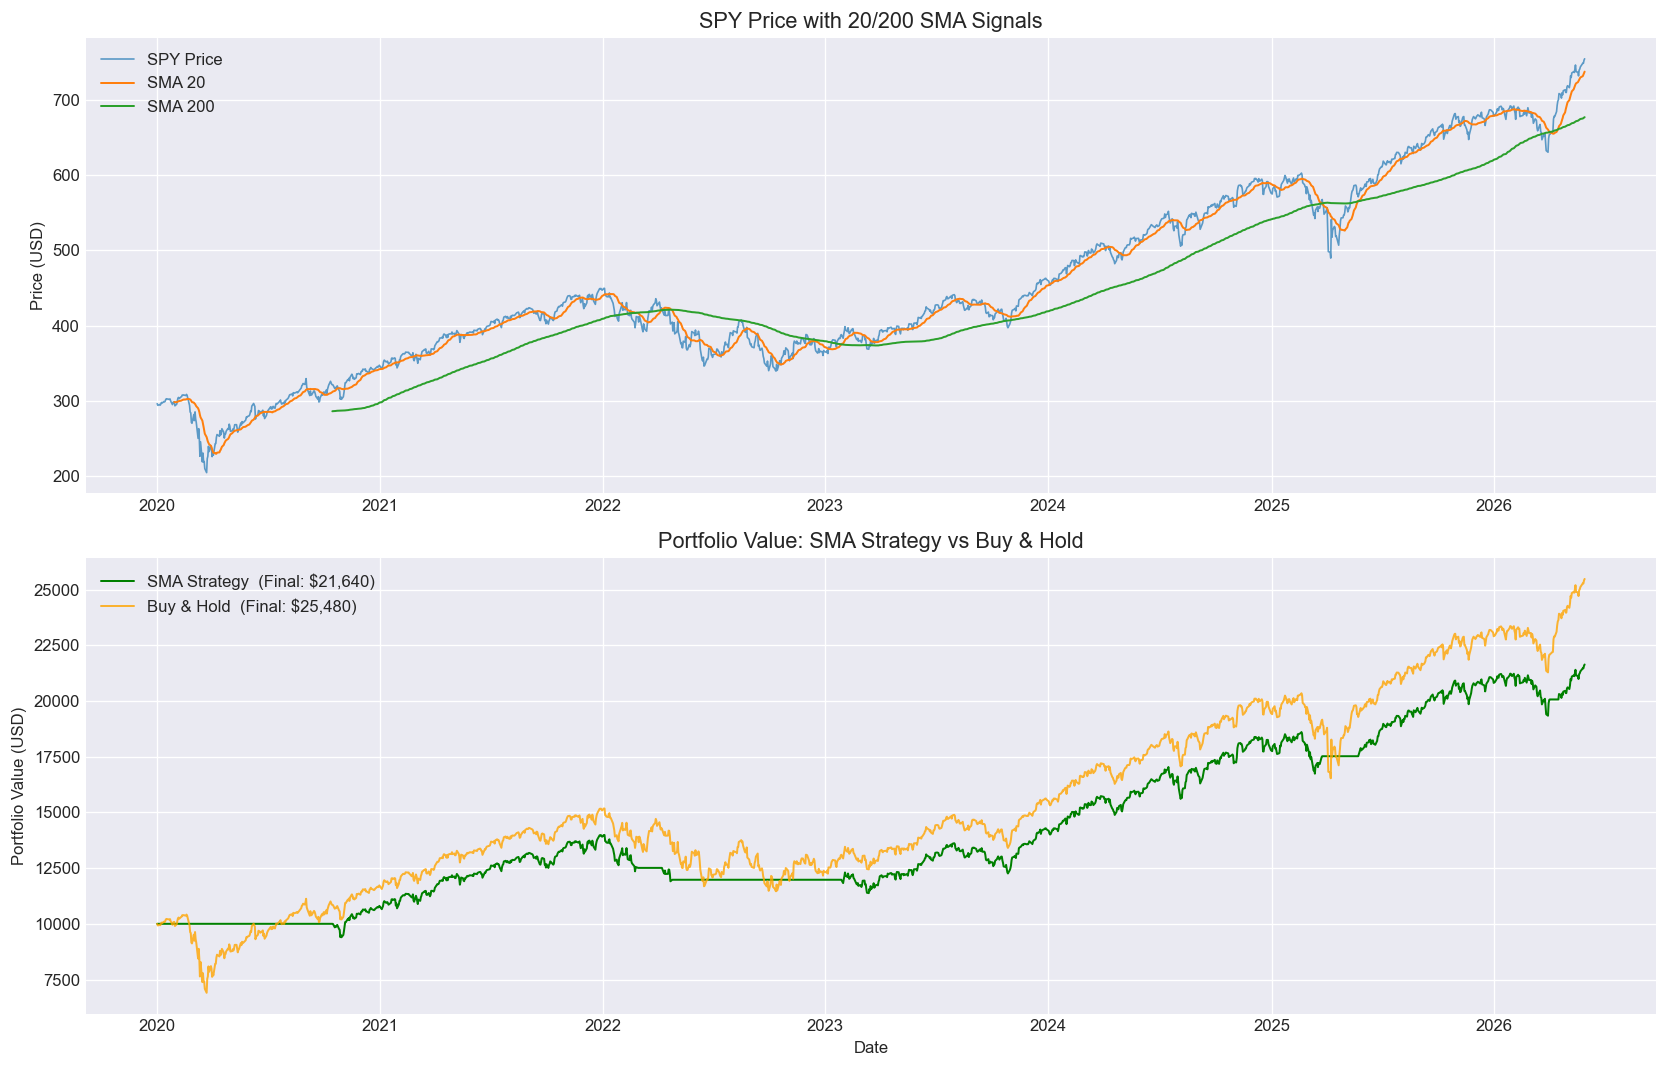

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14,9))

#Top: Price + SMAs
axes[0].plot(df["Close"], label="SPY Price", alpha=0.7, linewidth=1)
axes[0].plot(df["SMA_fast"], label="SMA 20", linewidth=1.2)
axes[0].plot(df["SMA_slow"], label="SMA 200", linewidth=1.2)
axes[0].set_title("SPY Price with 20/200 SMA Signals", fontsize=13)
axes[0].set_ylabel("Price (USD)")
axes[0].legend()

#Bottom: Portfolio vs Buy & Hold
axes[1].plot(df["portfolio"], color="green", label=f"SMA Strategy  (Final: ${strat_final:,.0f})", linewidth=1.2)
axes[1].plot(df["buy_hold"], color="orange", label=f"Buy & Hold  (Final: ${bh_final:,.0f})", alpha=0.8, linewidth=1.2)
axes[1].set_title("Portfolio Value: SMA Strategy vs Buy & Hold", fontsize=13)
axes[1].set_ylabel("Portfolio Value (USD)")
axes[1].set_xlabel("Date")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Conclusion

### Results Summary

Over the 2020–2026 period, **buy-and-hold outperformed the SMA crossover strategy** in total return. However, the SMA strategy shows a better (less negative) max drawdown, reflecting its defensive nature as it exits positions during downtrends and avoids some of the worst declines.

### Why does buy and hold win here?

1. **Bull market bias**: SPY trended strongly upward for most of 2020–2026. SMA crossover strategies underperform in sustained uptrends because they're always slightly late: they buy after the move has started and sell after it has already dropped.
2. **Time out of market**: When the signal is `-1`, the strategy sits in cash and misses gains during recovery rallies.
3. **Signal lag**: The 200-day SMA is very slow to react. By the time a golden cross fires, much of the upward move may have already happened.

### Limitations

1. **No transaction costs or slippage**: In reality, each trade incurs brokerage fees and bid-ask spread which would further reduce strategy returns.
2. **Single asset**: Tested on SPY only. Results may differ across assets, sectors, or time periods.
3. **No short selling**: The `-1` signal simply exits to cash rather than going short, leaving potential downside profits on the table.
4. **Survivorship bias**: SPY tracks the S&P 500, which periodically removes underperforming companies and replaces them with stronger ones. This means the index itself carries an inherent upward bias as the losers are always ejected. Any strategy benchmarked against SPY should be interpreted with this in mind.